# Qiskit Circuit Knitting：GHZ State preparation

透過Qis函數 **Qiskit Circuit Cutting Addon**，將一個 4-qubit GHZ 電路切成兩個 2-qubit subcircuits，分別執行後再重建

$$
\langle XXXX\rangle.
$$

Workflow：

1. Construct GHZ Circuit  
2. Choose observable $\langle XXXX\rangle.$  
3. Cutting the CNOT cross the two QPUs by `partition_problem()`  
4. Generate QPD subexperiments by  `generate_cutting_experiments()` 
5. Execute by `AerSamplerV2`   
6. reconstruct the EV by  `reconstruct_expectation_values()`   
7. Compare with origional circuit(without ck)  

**Packcage Versions**

- Qiskit 2.5.0
- Qiskit Aer 0.17.2
- qiskit-addon-cutting 0.10.0

## Cell 1：Install required packcages

In [1]:
%pip install -q "qiskit==2.5.0" "qiskit-aer==0.17.2" "qiskit-addon-cutting==0.10.0" matplotlib pylatexenc

Note: you may need to restart the kernel to use updated packages.


## Cell 2：Import packcages

In [2]:
import numpy as np
import qiskit
import qiskit_aer
import qiskit_addon_cutting

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer.primitives import SamplerV2
from qiskit_addon_cutting import (
    partition_problem,
    generate_cutting_experiments,
    reconstruct_expectation_values,
)

print("Qiskit version                 :", qiskit.__version__)
print("Qiskit Aer version             :", qiskit_aer.__version__)
print("Circuit Cutting Addon version  :", qiskit_addon_cutting.__version__)

Qiskit version                 : 2.5.0
Qiskit Aer version             : 0.17.2
Circuit Cutting Addon version  : 0.10.0


## Cell 3：Setting experiment parameters

- `SHOTS`： meansurement times for each subexperiment cutting
- `SEED` ： fixed Randomize seed for Reproducibility 
- `PARTITION_LABELS="AABB"`：
  - $q_0,q_1$ belongs to partition A
  - $q_2,q_3$belongs to partition B

In [3]:
N_QUBITS = 4
SHOTS = 8192
SEED = 412220419
NUM_QPD_SAMPLES = 8192
PARTITION_LABELS = "AABB"

assert len(PARTITION_LABELS) == N_QUBITS, (
    "PARTITION_LABELS and qubits should be same"
)

## Cell 4：Construct 4-qubit GHZ circuit

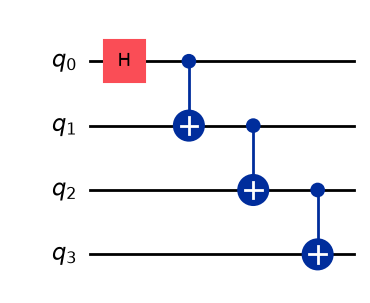

In [4]:
qc = QuantumCircuit(N_QUBITS, name="GHZ")

qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)  
qc.cx(2, 3)

display(qc.draw(output="mpl"))

## Cell 5： Observable

$$
|GHZ_4\rangle=\frac{|0000\rangle+|1111\rangle}{\sqrt{2}},
\qquad
\langle XXXX\rangle=1.
$$

In [5]:
observable = SparsePauliOp.from_list([("XXXX", 1.0)])

print("Observable:")
print(observable)
ideal_state = Statevector.from_instruction(qc)
exact_expectation = float(
    np.real(ideal_state.expectation_value(observable))
)

print(f"Exact <XXXX> = {exact_expectation:.12f}")

Observable:
SparsePauliOp(['XXXX'],
              coeffs=[1.+0.j])
Exact <XXXX> = 1.000000000000


## Cell 6：CK with qubit partition

`partition_problem()` find the partition of the non-local cross two-qubit gate, and tranfer to quasiprobability decomposition（QPD）.
   
https://quantum.cloud.ibm.com/docs/en/tutorials/depth-reduction-with-circuit-cutting .

https://qiskit.github.io/qiskit-addon-cutting/explanation/index.html

Partition labels: ['A', 'B']
Number of cut gates: 1
Partition A
- Local observable: ['XX']


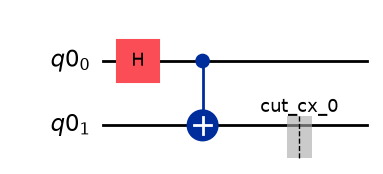

Partition B
- Local observable: ['XX']


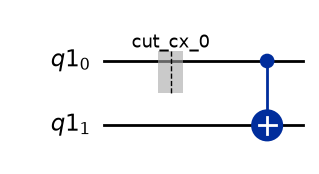

In [6]:
partitioned_problem = partition_problem(circuit=qc, partition_labels=PARTITION_LABELS, observables=observable.paulis,)

subcircuits = partitioned_problem.subcircuits
subobservables = partitioned_problem.subobservables
bases = partitioned_problem.bases

print("Partition labels:", list(subcircuits.keys()))
print("Number of cut gates:", len(bases))
for label in subcircuits:
    print("=" * 60)
    print(f"Partition {label}")
    print("- Local observable:", subobservables[label])
    display(subcircuits[label].draw(output="mpl", fold=-1))
print("=" * 60)

## Cell 7：Subcircuits

Partition A: 6 unique subexperiments
Partition B: 6 unique subexperiments
Number of reconstruction coefficients: 6
QPD sample index = 0
Coefficient      = 0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 0


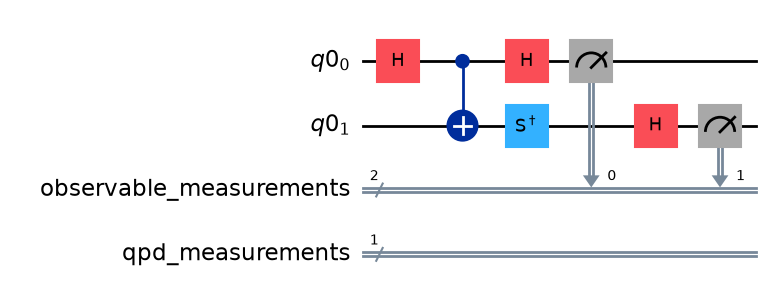


Partition B, subexperiment 0


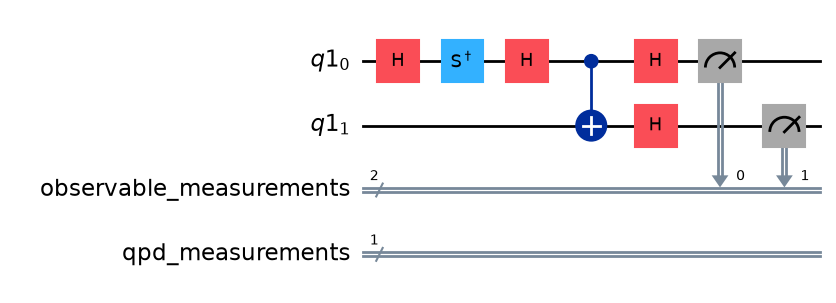

QPD sample index = 1
Coefficient      = 0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 1


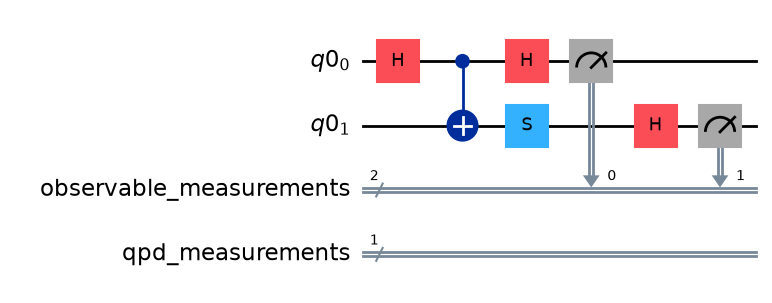


Partition B, subexperiment 1


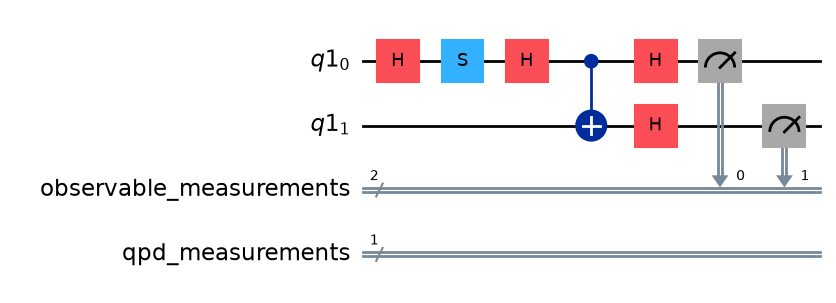

QPD sample index = 2
Coefficient      = 0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 2


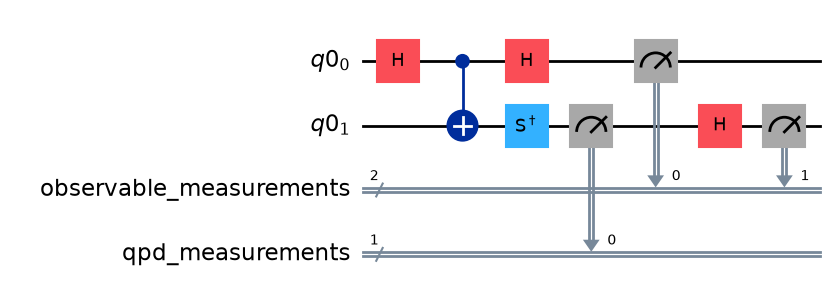


Partition B, subexperiment 2


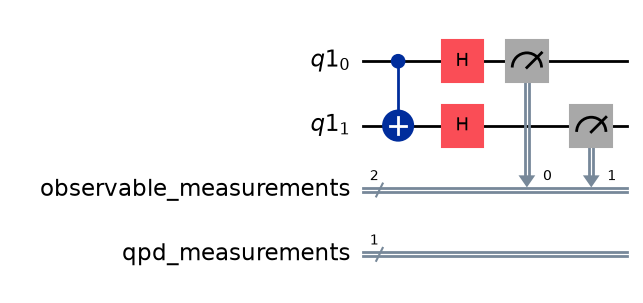

QPD sample index = 3
Coefficient      = -0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 3


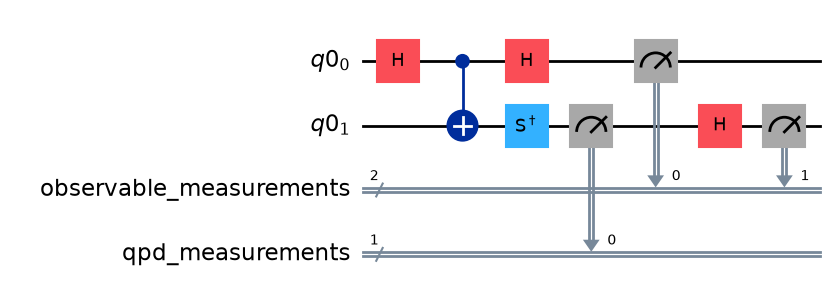


Partition B, subexperiment 3


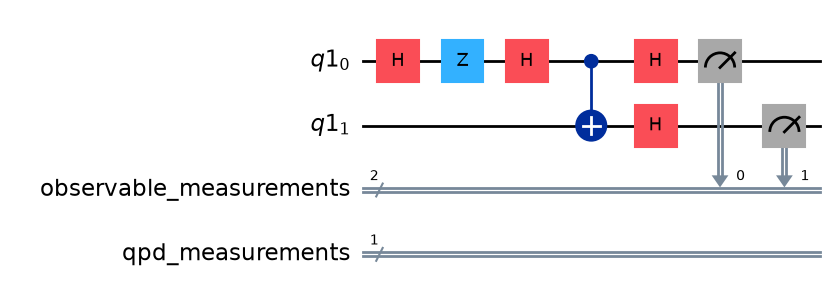

QPD sample index = 4
Coefficient      = 0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 4


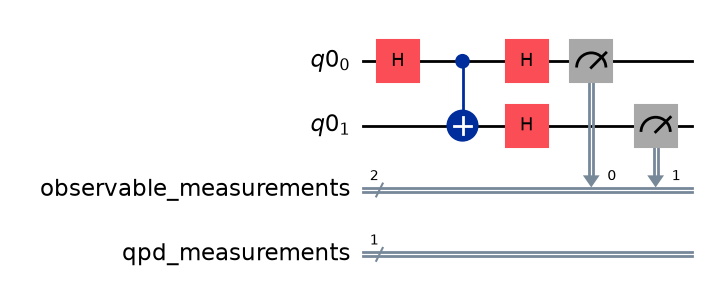


Partition B, subexperiment 4


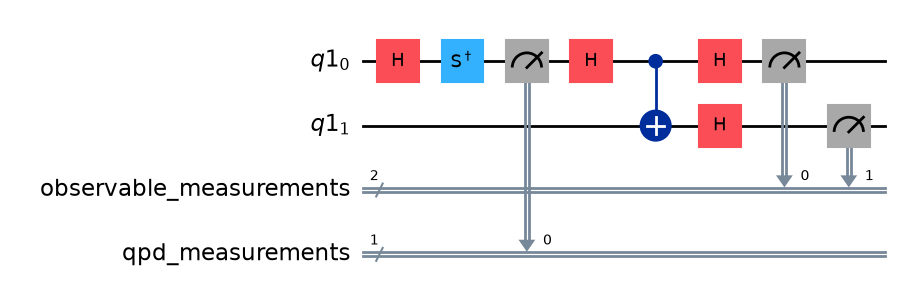

QPD sample index = 5
Coefficient      = -0.5
Weight type      = WeightType.EXACT

Partition A, subexperiment 5


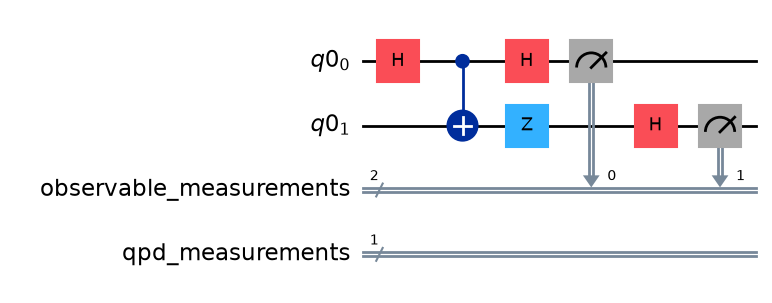


Partition B, subexperiment 5


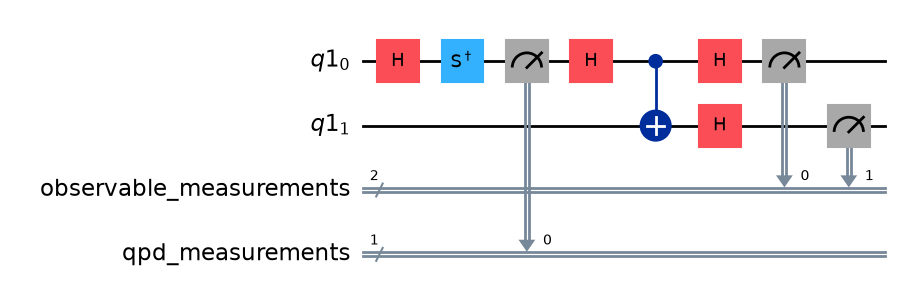

In [7]:
subexperiments, coefficients = generate_cutting_experiments(
    circuits=subcircuits,
    observables=subobservables,
    num_samples=NUM_QPD_SAMPLES,
)

for label, experiments in subexperiments.items():
    print(
        f"Partition {label}: "
        f"{len(experiments)} unique subexperiments"
    )

print("Number of reconstruction coefficients:", len(coefficients))

N_SHOW = len(coefficients)

for i in range(N_SHOW):
    coefficient, weight_type = coefficients[i]

    print("=" * 80)
    print(f"QPD sample index = {i}")
    print(f"Coefficient      = {coefficient}")
    print(f"Weight type      = {weight_type}")

    for label, experiments in subexperiments.items():
        print(f"\nPartition {label}, subexperiment {i}")
        display(
            experiments[i].draw(
                output="mpl",
                fold=-1,
            )
        )

## Cell8：Overhead

In [8]:
individual_overheads = [
    float(basis.overhead)
    for basis in bases
]

sampling_overhead = float(np.prod(individual_overheads))

print("Number of cuts            =", len(bases))
print("Overhead of each cut      =", individual_overheads)
print("Total sampling overhead   =", sampling_overhead)

Number of cuts            = 1
Overhead of each cut      = [9.0]
Total sampling overhead   = 9.0


## Cell 9：reconstructed EV

In [9]:
sampler = SamplerV2(default_shots=SHOTS,seed=SEED,)

results = {}

for label, experiments in subexperiments.items():
    job = sampler.run(
        experiments,
        shots=SHOTS,
    )
    results[label] = job.result()

reconstructed_terms = reconstruct_expectation_values(results=results, coefficients=coefficients, observables=subobservables,)

knitted_expectation = float(np.real(np.dot(reconstructed_terms,observable.coeffs,)))
absolute_error = abs(knitted_expectation - exact_expectation)

print(f"Target observable    : <XXXX>")
print(f"Exact expectation    = {exact_expectation:.12f}")
print(f"Knitted expectation  = {knitted_expectation:.12f}")
print(f"Absolute error        = {absolute_error:.12f}")
print(f"Shots per experiment  = {SHOTS}")
print(f"Sampling overhead     = {sampling_overhead}")

Target observable    : <XXXX>
Exact expectation    = 1.000000000000
Knitted expectation  = 1.000143468380
Absolute error        = 0.000143468380
Shots per experiment  = 8192
Sampling overhead     = 9.0


## Cell 10：Depolarizing gate noise and observable EV comparison

This cell does not modify `subcircuits` .  It only gives the Aer simulator a noise model during execution:

- single-qubit gates: depolarizing parameter $\lambda_{1q}=0.005$（0.5%）
- two-qubit gates: depolarizing parameter $\lambda_{2q}=0.01$（1%）

The same cutting experiments and reconstruction coefficients are used to reconstruct the noisy $\langle XXXX\rangle$ and compare it with the exact and noiseless circuit-knitting results.

Noisy single-qubit gates: ['h', 's', 'sdg', 'z']
Noisy two-qubit gates   : ['cx']

Noise model:
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 's', 'sdg', 'sx', 'z']
  Instructions with noise: ['h', 'z', 's', 'cx', 'sdg']
  All-qubits errors: ['h', 's', 'sdg', 'z', 'cx']
Partition A noisy execution finished: 6 results
Partition B noisy execution finished: 6 results

Observable EV comparison
Target observable                 : <XXXX>
Exact EV                          = 1.000000000000
Noiseless circuit-knitting EV     = 1.000143468380
Noisy circuit-knitting EV         = 0.767765849829
Noisy EV - noiseless EV           = -0.232377618551
EV reduction                      = 0.232377618551
Relative EV change                = -23.234428%
Noisy absolute error from exact   = 0.232234150171
1-qubit depolarizing parameter    = 0.0250
2-qubit depolarizing parameter    = 0.0500
Shots per subexperiment           = 8192


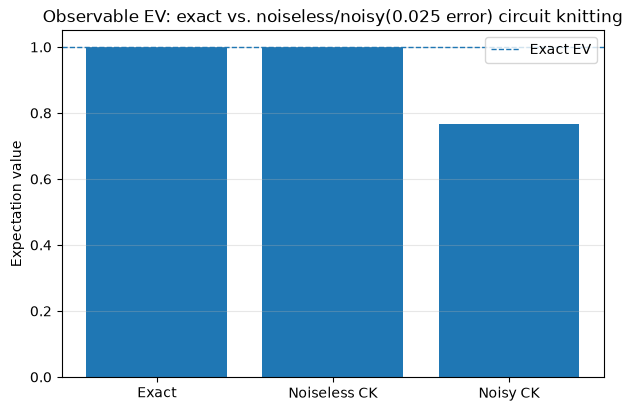

In [17]:
from qiskit.circuit import Gate
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

# 1. error strength parameter setting  

ONE_QUBIT_ERROR_RATE = 0.025  
TWO_QUBIT_ERROR_RATE = 0.05    

one_qubit_error = depolarizing_error(
    ONE_QUBIT_ERROR_RATE,
    1,
)

two_qubit_error = depolarizing_error(
    TWO_QUBIT_ERROR_RATE,
    2,
)



# 2. Find actual gate names in the generated subexperiments Gate .


single_qubit_gate_names = set()
two_qubit_gate_names = set()

for experiments in subexperiments.values():
    for experiment in experiments:
        for circuit_instruction in experiment.data:
            operation = circuit_instruction.operation

            if isinstance(operation, Gate):
                if operation.num_qubits == 1:
                    single_qubit_gate_names.add(operation.name)
                elif operation.num_qubits == 2:
                    two_qubit_gate_names.add(operation.name)

single_qubit_gate_names = sorted(single_qubit_gate_names)
two_qubit_gate_names = sorted(two_qubit_gate_names)

print("Noisy single-qubit gates:", single_qubit_gate_names)
print("Noisy two-qubit gates   :", two_qubit_gate_names)

# 3. Build  noise model

noise_model = NoiseModel()

if single_qubit_gate_names:
    noise_model.add_all_qubit_quantum_error(
        one_qubit_error,
        single_qubit_gate_names,
    )

if two_qubit_gate_names:
    noise_model.add_all_qubit_quantum_error(
        two_qubit_error,
        two_qubit_gate_names,
    )

print("\nNoise model:")
print(noise_model)

# 4. Execute the SAME subexperiments with noise

noisy_sampler = SamplerV2(
    default_shots=SHOTS,
    seed=SEED,
    options={
        "backend_options": {
            "noise_model": noise_model,
        }
    },
)

noisy_results = {}

for label, experiments in subexperiments.items():
    noisy_job = noisy_sampler.run(
        experiments,
        shots=SHOTS,
    )

    noisy_results[label] = noisy_job.result()

    print(
        f"Partition {label} noisy execution finished: "
        f"{len(noisy_results[label])} results"
    )



# 5. Reconstruct the noisy full-circuit observable EV


noisy_reconstructed_terms = reconstruct_expectation_values(
    results=noisy_results,
    coefficients=coefficients,
    observables=subobservables,
)

noisy_knitted_expectation = float(
    np.real(
        np.dot(
            noisy_reconstructed_terms,
            observable.coeffs,
        )
    )
)

noisy_absolute_error = abs(
    noisy_knitted_expectation - exact_expectation
)

ev_change = noisy_knitted_expectation - knitted_expectation

ev_reduction = knitted_expectation - noisy_knitted_expectation

if abs(knitted_expectation) > 1e-15:
    relative_ev_change_percent = (
        ev_change / abs(knitted_expectation) * 100.0
    )
else:
    relative_ev_change_percent = np.nan

# 6. Display the observable-EV change


print("\n" + "=" * 65)
print("Observable EV comparison")
print("=" * 65)
print(f"Target observable                 : <XXXX>")
print(f"Exact EV                          = {exact_expectation:.12f}")
print(f"Noiseless circuit-knitting EV     = {knitted_expectation:.12f}")
print(f"Noisy circuit-knitting EV         = {noisy_knitted_expectation:.12f}")
print(f"Noisy EV - noiseless EV           = {ev_change:+.12f}")
print(f"EV reduction                      = {ev_reduction:.12f}")
print(f"Relative EV change                = {relative_ev_change_percent:+.6f}%")
print(f"Noisy absolute error from exact   = {noisy_absolute_error:.12f}")
print(f"1-qubit depolarizing parameter    = {ONE_QUBIT_ERROR_RATE:.4f}")
print(f"2-qubit depolarizing parameter    = {TWO_QUBIT_ERROR_RATE:.4f}")
print(f"Shots per subexperiment           = {SHOTS}")



labels = [
    "Exact",
    "Noiseless CK",
    "Noisy CK",
]

values = [
    exact_expectation,
    knitted_expectation,
    noisy_knitted_expectation,
]

plt.figure(figsize=(7, 4.5))
plt.bar(labels, values)
plt.axhline(
    exact_expectation,
    linestyle="--",
    linewidth=1,
    label="Exact EV",
)
plt.ylabel("Expectation value")
plt.title("Observable EV: exact vs. noiseless/noisy({} error) circuit knitting".format(ONE_QUBIT_ERROR_RATE))
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## Cell 11：error rate scanning

Noisy 1-qubit gates: ['h', 's', 'sdg', 'z']
Noisy 2-qubit gates: ['cx']

Point 1/250
1-qubit error = 0.000%
2-qubit error = 0.000%
  repeat 1: EV = 1.00014347

Point 2/250
1-qubit error = 0.200%
2-qubit error = 0.400%
  repeat 1: EV = 0.97696453

Point 3/250
1-qubit error = 0.400%
2-qubit error = 0.800%
  repeat 1: EV = 0.95730314

Point 4/250
1-qubit error = 0.600%
2-qubit error = 1.200%
  repeat 1: EV = 0.93686759

Point 5/250
1-qubit error = 0.800%
2-qubit error = 1.600%
  repeat 1: EV = 0.91040123

Point 6/250
1-qubit error = 1.000%
2-qubit error = 2.000%
  repeat 1: EV = 0.89322612

Point 7/250
1-qubit error = 1.200%
2-qubit error = 2.400%
  repeat 1: EV = 0.88471970

Point 8/250
1-qubit error = 1.400%
2-qubit error = 2.800%
  repeat 1: EV = 0.85731390

Point 9/250
1-qubit error = 1.600%
2-qubit error = 3.200%
  repeat 1: EV = 0.84279227

Point 10/250
1-qubit error = 1.800%
2-qubit error = 3.600%
  repeat 1: EV = 0.83009204

Point 11/250
1-qubit error = 2.000%
2-qubit error = 4.00

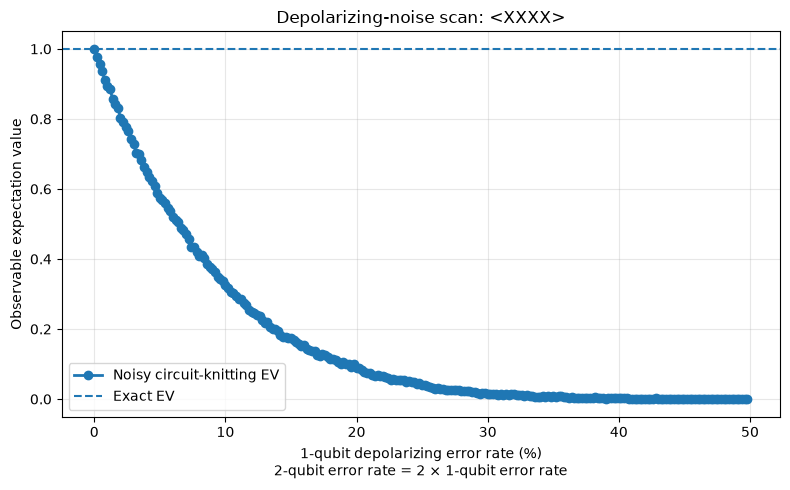

In [20]:
from qiskit.circuit import Gate
from qiskit_aer.noise import NoiseModel, depolarizing_error
import numpy as np
import matplotlib.pyplot as plt


# 1. Error-rate scan settings

# 1-qubit error
ONE_QUBIT_ERROR_RATES = np.arange(
    0.0,
    0.50,
    0.002,
)
ERROR_RATE_RATIO = 2.0

TWO_QUBIT_ERROR_RATES = (
    ERROR_RATE_RATIO
    * ONE_QUBIT_ERROR_RATES
)

SCAN_SHOTS = SHOTS
N_REPEATS = 1


# 2. Detect gates appearing in subexperiments

single_qubit_gate_names = set()
two_qubit_gate_names = set()

for experiments in subexperiments.values():
    for experiment in experiments:
        for instruction in experiment.data:

            operation = instruction.operation
            if isinstance(operation, Gate):

                if operation.num_qubits == 1:
                    single_qubit_gate_names.add(
                        operation.name
                    )

                elif operation.num_qubits == 2:
                    two_qubit_gate_names.add(
                        operation.name
                    )


single_qubit_gate_names = sorted(single_qubit_gate_names)

two_qubit_gate_names = sorted(two_qubit_gate_names)


print("Noisy 1-qubit gates:", single_qubit_gate_names,)

print("Noisy 2-qubit gates:", two_qubit_gate_names,)


ev_all_repeats = np.zeros(
    (len(ONE_QUBIT_ERROR_RATES), N_REPEATS,),
    dtype=float,
)


# 4. scan error rates

for rate_index, (one_qubit_rate, two_qubit_rate,) in enumerate(zip(ONE_QUBIT_ERROR_RATES, TWO_QUBIT_ERROR_RATES,)):

    print(
        f"\nPoint {rate_index + 1}/"
        f"{len(ONE_QUBIT_ERROR_RATES)}"
    )

    print(
        f"1-qubit error = "
        f"{100 * one_qubit_rate:.3f}%"
    )

    print(
        f"2-qubit error = "
        f"{100 * two_qubit_rate:.3f}%"
    )

    for repeat_index in range(N_REPEATS):
        scan_noise_model = NoiseModel()

        if one_qubit_rate > 0:

            one_qubit_error = depolarizing_error(one_qubit_rate, 1,)

            scan_noise_model.add_all_qubit_quantum_error(
                one_qubit_error,
                single_qubit_gate_names,
            )

        if two_qubit_rate > 0:

            two_qubit_error = depolarizing_error(
                two_qubit_rate,
                2,
            )

            scan_noise_model.add_all_qubit_quantum_error(
                two_qubit_error,
                two_qubit_gate_names,
            )


        scan_seed = (
            SEED
            + 1000 * rate_index
            + repeat_index
        )

        scan_sampler = SamplerV2(
            default_shots=SCAN_SHOTS,
            seed=scan_seed,
            options={
                "backend_options": {
                    "noise_model": scan_noise_model,
                }
            },
        )


        # Execute the same cutting subexperiments


        scan_results = {}

        for label, experiments in subexperiments.items():

            scan_results[label] = scan_sampler.run(
                experiments,
                shots=SCAN_SHOTS,
            ).result()

        # Reconstruct full observable EV

        scan_reconstructed_terms = (reconstruct_expectation_values(results=scan_results, coefficients=coefficients, observables=subobservables,))

        scan_ev = float(np.real(np.dot(scan_reconstructed_terms, observable.coeffs,)))

        ev_all_repeats[rate_index, repeat_index,] = scan_ev

        print(
            f"  repeat {repeat_index + 1}: "
            f"EV = {scan_ev:.8f}"
        )



# 5. Calculate mean and standard deviation


ev_mean = np.mean(
    ev_all_repeats,
    axis=1,
)

if N_REPEATS > 1:

    ev_std = np.std(
        ev_all_repeats,
        axis=1,
        ddof=1,
    )

else:

    ev_std = np.zeros_like(ev_mean)



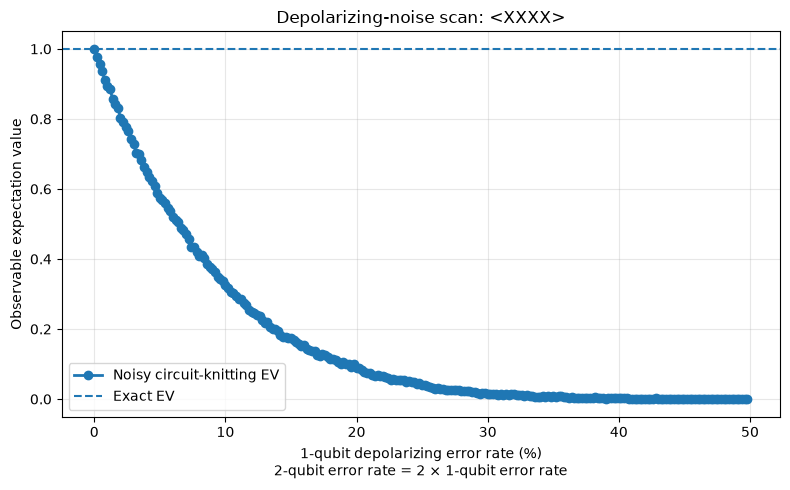

In [22]:

# 7. Plot expectation-value curve


one_qubit_percent = (
    100
    * ONE_QUBIT_ERROR_RATES
)

plt.figure(
    figsize=(8, 5),
)

# EV average curve
plt.plot(
    one_qubit_percent,
    ev_mean,
    marker="o",
    linewidth=2,
    label="Noisy circuit-knitting EV",
)

# Exact reference
plt.axhline(
    exact_expectation,
    linestyle="--",
    linewidth=1.5,
    label="Exact EV",
)



plt.xlabel(
    "1-qubit depolarizing error rate (%)\n"
    "2-qubit error rate = 2 × 1-qubit error rate"
)

plt.ylabel(
    "Observable expectation value"
)

observable_name = " + ".join(
    observable.paulis.to_labels()
)

plt.title(
    f"Depolarizing-noise scan: "
    f"<{observable_name}>"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend()
plt.tight_layout()
plt.show()